# Semi-synthetic results — paper mock-up

This notebook is ready for the multi-dataset CoxPH-margin experiment with Gaussian, Clayton, Frank, and Gumbel copulas. It prefers `results/semi-synthetic/results_raw.csv`, then completed per-dataset job results, and otherwise generates deterministic mock rows.

The mock values are illustrative and must never be reported. The semi-synthetic cohorts retain each source dataset's original censoring rate.

In [1]:
from pathlib import Path
import os
import re
import shutil
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "large",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "savefig.bbox": "tight",
})

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
CONFIG_PATH = ROOT / "configs" / "semi_synthetic.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)
RESULT_CANDIDATES = [ROOT / "results" / "semi-synthetic", ROOT / "results" / "semi-synthetic-support"]
FIGURE_DIR = ROOT / "paper" / "figures"
TABLE_DIR = ROOT / "paper" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
RANK_COPULA = "Clayton"
TARGET_TAU = 0.50

In [2]:
def snake_case(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

def canonicalize(frame):
    out = frame.rename(columns={column: snake_case(column) for column in frame.columns}).copy()
    aliases = {
        "dataset_name": "dataset", "target_censoring": "target_censoring_rate",
        "censoring_rate": "target_censoring_rate", "kendall_tau": "target_kendall_tau",
        "oracle_joint_ise": "oracle_joint_survival_ise",
    }
    out = out.rename(columns={key: value for key, value in aliases.items() if key in out and value not in out})
    if "model" in out:
        names = {"dvfm": "DVFM", "coxph": "CoxPH", "deepsurv": "DeepSurv", "rsf": "RSF", "gbsa": "GBSA", "mtlr": "MTLR", "deephit": "DeepHit", "hacsurv": "HACSurv", "hacsurv_2d": "HACSurv", "clayton_aft": "ClaytonAFT", "bayesian_cox_gamma_frailty": "BayesianCoxGammaFrailty", "bayesiancoxgammafrailty": "BayesianCoxGammaFrailty"}
        out["model"] = out["model"].astype(str).str.lower().map(names).fillna(out["model"].astype(str))
        if "latent_dim" in out:
            latent_dim = pd.to_numeric(out["latent_dim"], errors="coerce")
            nonprimary = out["model"].eq("DVFM") & latent_dim.ne(1) & latent_dim.notna()
            out.loc[nonprimary, "model"] = latent_dim.loc[nonprimary].map(lambda value: f"DVFM-z{int(value)}")
    if "copula" in out:
        out["copula"] = out["copula"].astype(str).str.title()
    return out

def make_mock_semisynthetic(seed=2026):
    rng = np.random.default_rng(seed)
    datasets = [item["name"] for item in config["data"]["datasets"]]
    copulas = [name.title() for name in config["data"]["copulas"]]
    tau_values = [float(value) for value in config["data"]["kendall_tau"]]
    models = ["CoxPH", "DeepSurv", "MTLR", "RSF", "GBSA", "ClaytonAFT", "HACSurv", "BayesianCoxGammaFrailty", "DVFM", "DVFM-z0"]
    model_shift = {"DVFM": -0.020, "DVFM-z0": 0.000, "CoxPH": 0.006, "DeepSurv": 0.002, "MTLR": 0.001, "RSF": 0.004, "GBSA": 0.000, "ClaytonAFT": -0.006, "HACSurv": -0.010, "BayesianCoxGammaFrailty": -0.004}
    original_censoring = dict(zip(datasets, [0.570, 0.564, 0.421, 0.524, 0.364, 0.725, 0.320, 0.762, 0.667, 0.401, 0.376, 0.434]))
    rows = []
    for d, dataset in enumerate(datasets):
        dataset_effect = rng.normal(0, 0.012)
        for target_tau in tau_values:
            condition_copulas = ["Independence"] if np.isclose(target_tau, 0.0) else copulas
            for copula in condition_copulas:
                mismatch = {"Independence": 0.000, "Gaussian": 0.000, "Clayton": -0.004, "Frank": 0.004, "Gumbel": -0.002}[copula]
                for censoring in (original_censoring[dataset],):
                    for repeat in range(10):
                        shared_noise = rng.normal(0, 0.003)
                        for model in models:
                            dependence_gain = (target_tau * censoring) if model in {"DVFM", "HACSurv", "ClaytonAFT"} else 0.0
                            ibs = 0.125 + dataset_effect + 0.055 * censoring + model_shift[model] - 0.018 * dependence_gain + shared_noise + rng.normal(0, 0.003)
                            learned = np.nan
                            joint_ise = np.nan
                            frailty = np.nan
                            if model == "DVFM":
                                learned = np.clip(target_tau + mismatch - 0.035 * censoring + rng.normal(0, 0.025), 0, 1)
                                joint_ise = 0.010 + 0.025 * censoring + abs(mismatch) + rng.normal(0, 0.002)
                                frailty = np.clip(0.78 - 0.24 * censoring + {"Independence": 0.0, "Gaussian": 0.04, "Clayton": 0.00, "Frank": -0.10, "Gumbel": -0.03}[copula] + rng.normal(0, 0.035), -1, 1)
                            elif model == "HACSurv":
                                learned = np.clip(target_tau + 0.045 + mismatch + rng.normal(0, 0.04), 0, 1)
                                joint_ise = 0.016 + 0.032 * censoring + abs(mismatch) + rng.normal(0, 0.003)
                            rows.append({
                                "dataset": dataset, "copula": copula, "target_kendall_tau": target_tau,
                                "target_censoring_rate": censoring, "repeat": repeat, "model": model,
                                "oracle_ibs": ibs,
                                "oracle_ci": 0.75 - 0.55 * (ibs - 0.12) + rng.normal(0, 0.007),
                                "oracle_mae": 0.75 + 3.2 * ibs + rng.normal(0, 0.035),
                                "frailty_spearman": frailty,
                                "learned_conditional_kendall_tau": learned,
                                "absolute_conditional_kendall_tau_error": abs(learned - target_tau) if np.isfinite(learned) else np.nan,
                                "oracle_joint_survival_ise": joint_ise, "numerical_failure": False,
                            })
    characteristics = pd.DataFrame({
        "Dataset": datasets,
        "$N$": [500, 686, 1902, 1958, 2396, 7871, 8873, 14999, 38520, 73703, 82841, 100360],
        "Raw features": [14, 8, 9, 12, 48, 8, 14, 8, 91, 10, 14, 14],
        "Encoded features": [14, 8, 9, 25, 48, 16, 27, 17, 103, 10, 14, 14],
        "Original censoring rate": [0.570, 0.564, 0.421, 0.524, 0.364, 0.725, 0.320, 0.762, 0.667, 0.401, 0.376, 0.434],
        "Split": ["70/10/20"] * 12,
    })
    return pd.DataFrame(rows), characteristics

result_path = next((path / "results_raw.csv" for path in RESULT_CANDIDATES if (path / "results_raw.csv").exists()), None)
if result_path is not None:
    # Preferred: the GWF aggregate at results/semi-synthetic/results_raw.csv.
    results = canonicalize(pd.read_csv(result_path))
    characteristics_path = result_path.parent / "dataset_characteristics.csv"
    characteristics = pd.read_csv(characteristics_path) if characteristics_path.exists() else None
    DATA_SOURCE = "REAL RESULTS (cross-dataset aggregate)"
else:
    # While the aggregate target is pending, make completed dataset jobs usable.
    dataset_result_paths = [
        result for root in RESULT_CANDIDATES if root.exists()
        for result in sorted(root.glob("*/results_raw.csv"))
    ]
    if dataset_result_paths:
        results = canonicalize(pd.concat((pd.read_csv(path) for path in dataset_result_paths), ignore_index=True))
        characteristics = None
        DATA_SOURCE = f"REAL RESULTS ({len(dataset_result_paths)} dataset job(s))"
    else:
        results, characteristics = make_mock_semisynthetic()
        DATA_SOURCE = "MOCK DATA — DO NOT REPORT"
required = {"dataset", "copula", "target_censoring_rate", "repeat", "model", "oracle_ibs"}
missing = required - set(results.columns)
if missing:
    raise ValueError(f"Results are missing canonical columns: {sorted(missing)}")
CONFIG_TAU_VALUES = [float(value) for value in config["data"]["kendall_tau"]]
CONFIG_POSITIVE_COPULAS = {name.title() for name in config["data"]["copulas"]}
tau = pd.to_numeric(results["target_kendall_tau"], errors="coerce")
configured_tau = np.isclose(tau.to_numpy()[:, None], np.asarray(CONFIG_TAU_VALUES)).any(axis=1)
configured_copula = (np.isclose(tau, 0.0) & results["copula"].eq("Independence")) | (~np.isclose(tau, 0.0) & results["copula"].isin(CONFIG_POSITIVE_COPULAS))
results = results.loc[configured_tau & configured_copula].copy()
if results.empty:
    raise ValueError("No rows match the active semi_synthetic.yaml condition grid.")
print(DATA_SOURCE, f"| rows={len(results):,} | datasets={results['dataset'].nunique()}")

MOCK DATA — DO NOT REPORT | rows=15,600 | datasets=12


## Supplementary frailty-recovery hexbin plot

Hexbin density makes the subject-level recovery relationship legible without overplotting. The validation-derived calibration is retained; no test subjects are used to fit its affine mapping.

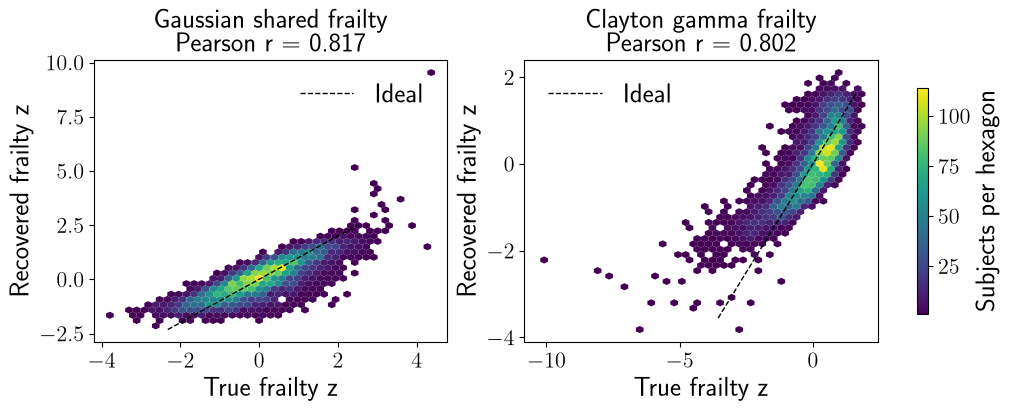

Subject hexbin source: results\frailty-recovery-diagnostic\subject_latent_diagnostics.csv.gz | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_frailty_recovery_hexbin.pdf


In [3]:
MECHANISM_LABELS = {
    "gaussian_shared_frailty": "Gaussian shared frailty",
    "clayton_gamma_frailty": "Clayton gamma frailty",
}
DIAGNOSTIC_SUBJECTS_PATH = ROOT / "results" / "frailty-recovery-diagnostic" / "subject_latent_diagnostics.csv.gz"

if DIAGNOSTIC_SUBJECTS_PATH.exists():
    subjects = pd.read_csv(DIAGNOSTIC_SUBJECTS_PATH)
    SUBJECT_HEXBIN_SOURCE = str(DIAGNOSTIC_SUBJECTS_PATH.relative_to(ROOT))
else:
    # Deterministic fallback preserves the schema and two-mechanism layout.
    rng = np.random.default_rng(2028)
    fallback = []
    for mechanism, noise in [("gaussian_shared_frailty", 0.36), ("clayton_gamma_frailty", 0.46)]:
        true_z = rng.normal(size=3_000)
        fallback.append(pd.DataFrame({
            "architecture": "dvfm", "training_variant": "current",
            "checkpoint": "final", "split": "test",
            "mechanism": mechanism, "true_z": true_z,
            "frailty_z_calibrated": 0.88 * true_z + rng.normal(0, noise, len(true_z)),
        }))
    subjects = pd.concat(fallback, ignore_index=True)
    SUBJECT_HEXBIN_SOURCE = "deterministic fallback"

current_subjects = subjects.query(
    "architecture == 'dvfm' and training_variant == 'current' and checkpoint == 'final' and split == 'test'"
).copy()
if current_subjects.empty:
    raise ValueError("No current/final/test DVFM subjects were found for the hexbin figure.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
image = None
for ax, (mechanism, label) in zip(axes, MECHANISM_LABELS.items()):
    part = current_subjects[current_subjects["mechanism"] == mechanism]
    if part.empty:
        ax.set_axis_off()
        ax.set_title(f"{label}\nnot available")
        continue
    image = ax.hexbin(
        part["true_z"], part["frailty_z_calibrated"],
        gridsize=42, mincnt=1, cmap="viridis", linewidths=0,
    )
    limits = np.nanpercentile(
        np.r_[part["true_z"], part["frailty_z_calibrated"]], [0.5, 99.5]
    )
    ax.plot(limits, limits, "--", color="black", linewidth=1, label="Ideal")
    correlation = part[["true_z", "frailty_z_calibrated"]].corr().iloc[0, 1]
    ax.set(title=f"{label}\nPearson r = {correlation:.3f}", xlabel="True frailty z", ylabel="Recovered frailty z")
    ax.legend(frameon=False)
if image is not None:
    fig.colorbar(image, ax=axes, label="Subjects per hexagon", shrink=0.8)
out = FIGURE_DIR / "semi_synthetic_frailty_recovery_hexbin.pdf"
fig.savefig(out)
plt.show()
print(f"Subject hexbin source: {SUBJECT_HEXBIN_SOURCE} | wrote {out}")


## Figure 1: model ranks across semi-synthetic datasets

For the fixed main-paper condition (Clayton, $\tau=0.50$), each metric is averaged over the ten seeds within a dataset, then models are ranked within that dataset. Rank 1 is best. Points show median ranks over datasets; horizontal bars are 95% non-parametric bootstrap intervals obtained by resampling datasets.

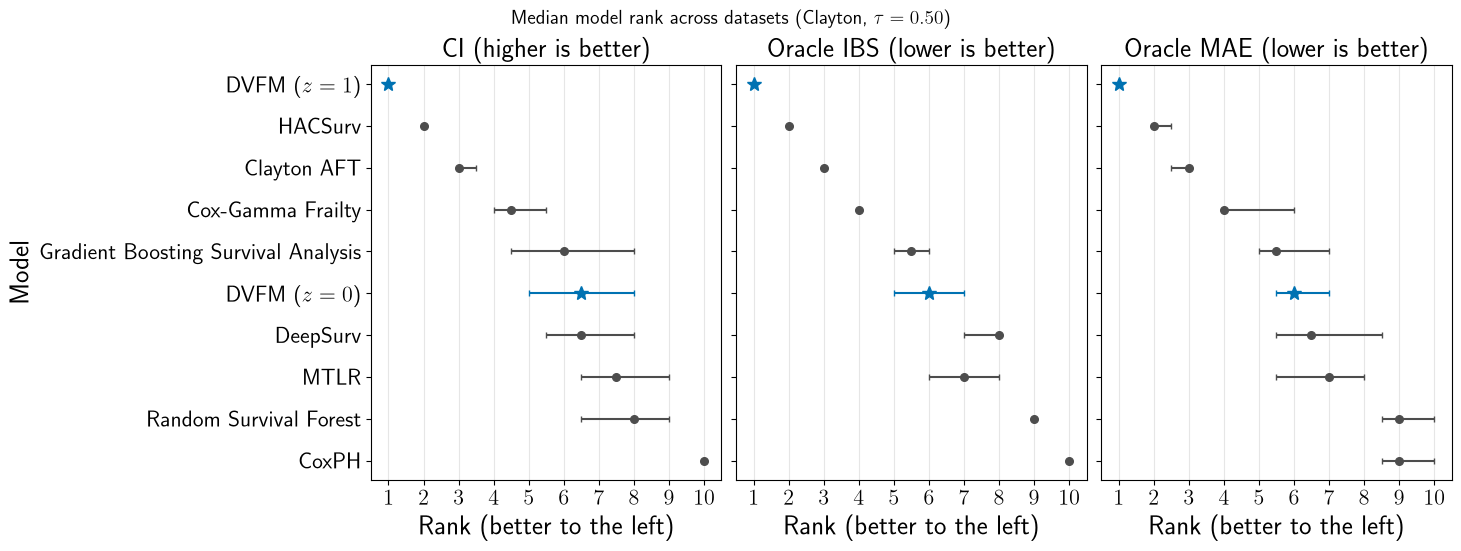

MOCK DATA — DO NOT REPORT | 12 datasets; 20,000 dataset bootstraps | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_model_ranks.pdf


In [4]:
RANK_METRICS = {
    "oracle_ci": ("CI (higher is better)", True),
    "oracle_ibs": ("Oracle IBS (lower is better)", False),
    "oracle_mae": ("Oracle MAE (lower is better)", False),
}
N_BOOTSTRAPS = 20_000
BOOTSTRAP_SEED = 2026
MODEL_LABELS = {
    "DVFM": "DVFM ($z=1$)", "DVFM-z0": "DVFM ($z=0$)",
    "BayesianCoxGammaFrailty": "Cox-Gamma Frailty",
    "RSF": "Random Survival Forest",
    "GBSA": "Gradient Boosting Survival Analysis",
    "ClaytonAFT": "Clayton AFT", "HACSurv": "HACSurv",
}

rank_input = results[
    results["copula"].eq(RANK_COPULA)
    & np.isclose(results["target_kendall_tau"], TARGET_TAU)
].copy()
if rank_input.empty:
    raise ValueError(f"No results for {RANK_COPULA}, tau={TARGET_TAU:.2f}.")

# The bootstrap unit is a dataset. Seed-level measurements are first combined
# within each dataset, so repeated training/sampling runs do not inflate n.
rank_tables = {}
for metric, (_, higher_is_better) in RANK_METRICS.items():
    by_dataset = rank_input.groupby(["dataset", "model"], as_index=False)[metric].mean()
    scores = by_dataset.pivot(index="dataset", columns="model", values=metric)
    scores = scores if higher_is_better else -scores
    # A failed/missing result is assigned the worst attainable rank.
    rank_tables[metric] = scores.fillna(-np.inf).rank(axis=1, ascending=False, method="average")

models = sorted(set.intersection(*(set(table.columns) for table in rank_tables.values())))
if not models:
    raise ValueError("No model has all three rank metrics.")
rank_tables = {metric: table.reindex(columns=models) for metric, table in rank_tables.items()}
median_ranks = pd.DataFrame({metric: table.median(axis=0) for metric, table in rank_tables.items()})
model_order = median_ranks.mean(axis=1).sort_values().index.tolist()

rng = np.random.default_rng(BOOTSTRAP_SEED)
rank_intervals = {}
for metric, ranks in rank_tables.items():
    values = ranks.reindex(columns=model_order).to_numpy(dtype=float)
    sampled_rows = rng.integers(0, len(values), size=(N_BOOTSTRAPS, len(values)))
    bootstrap_medians = np.median(values[sampled_rows], axis=1)
    rank_intervals[metric] = pd.DataFrame(
        {"median": np.median(values, axis=0),
         "low": np.quantile(bootstrap_medians, 0.025, axis=0),
         "high": np.quantile(bootstrap_medians, 0.975, axis=0)},
        index=model_order,
    )

fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.4), sharey=True, constrained_layout=True)
positions = np.arange(len(model_order))
for axis, (metric, (title, _)) in zip(axes, RANK_METRICS.items()):
    interval = rank_intervals[metric].loc[model_order]
    for y_pos, (model, row) in enumerate(interval.iterrows()):
        is_dvfm = model.startswith("DVFM")
        axis.errorbar(
            row["median"], y_pos, xerr=[[row["median"] - row["low"]], [row["high"] - row["median"]]],
            fmt="*" if is_dvfm else "o", markersize=10 if is_dvfm else 5.5,
            capsize=2.5, color="#0072B2" if is_dvfm else "#4D4D4D",
        )
    axis.set(title=title, xlabel="Rank (better to the left)", xlim=(0.5, len(model_order) + 0.5))
    axis.set_xticks(np.arange(1, len(model_order) + 1))
    axis.grid(axis="x", color="0.9", linewidth=0.8)
axes[0].set(yticks=positions, yticklabels=[MODEL_LABELS.get(model, model) for model in model_order], ylabel="Model")
axes[0].invert_yaxis()
fig.suptitle(rf"Median model rank across datasets ({RANK_COPULA}, $\tau={TARGET_TAU:.2f}$)", fontsize=14)
out = FIGURE_DIR / "semi_synthetic_model_ranks.pdf"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"{DATA_SOURCE} | {len(rank_tables['oracle_ci'])} datasets; {N_BOOTSTRAPS:,} dataset bootstraps | wrote {out}")

## Figure 2: recovery and mechanistic prediction benefit

The horizontal axis is target Kendall's $\tau$, the active experimental factor. For each dataset, metrics are averaged over seeds before pooling; intervals use datasets—not pooled subjects or seeds—as the unit of uncertainty. Each dataset retains its original censoring rate, which is deliberately not used as a plotting stratum.

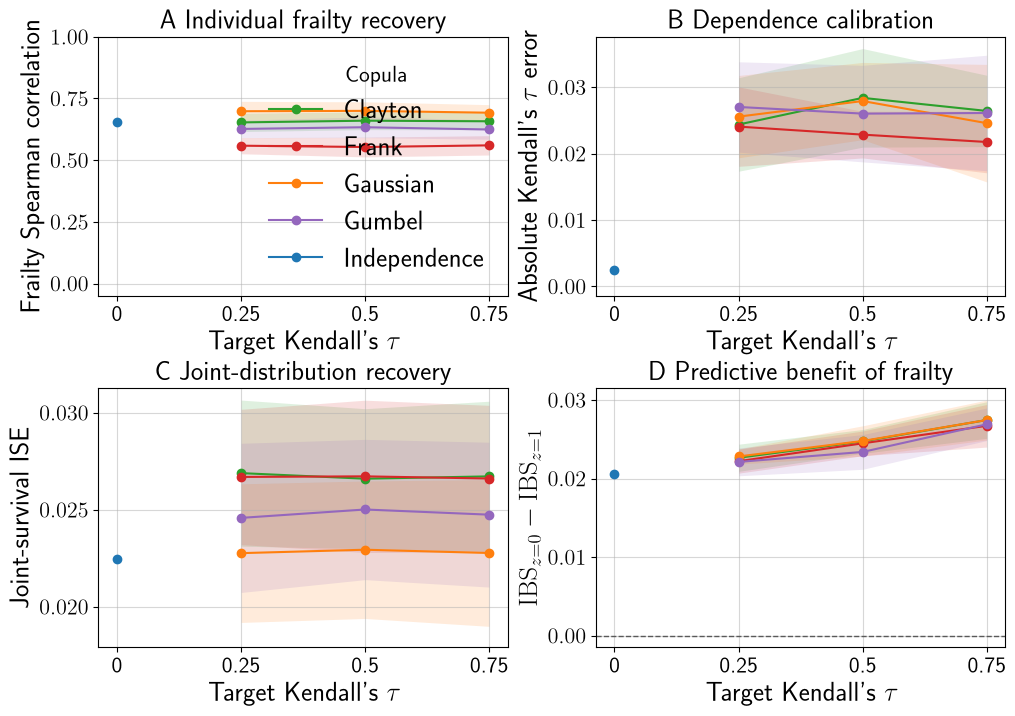

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_recovery.pdf


In [5]:
def dataset_balanced_summary(frame, metric, sigma_level=1.0):
    # Average seeds within each dataset, then quantify cross-dataset variation.
    per_dataset = frame.groupby(["dataset", "copula", "target_kendall_tau"], as_index=False)[metric].mean()
    out = per_dataset.groupby(["copula", "target_kendall_tau"])[metric].agg(["mean", "std", "count"]).reset_index()
    out["error"] = sigma_level * out["std"].fillna(0)
    return out

dvfm = results[results["model"].eq("DVFM")].copy()
mechanistic = results[results["model"].isin(["DVFM", "DVFM-z0"])].pivot_table(
    index=["dataset", "copula", "target_kendall_tau", "repeat"], columns="model", values="oracle_ibs"
).dropna().reset_index()
mechanistic["oracle_ibs_gain"] = mechanistic["DVFM-z0"] - mechanistic["DVFM"]
summaries = [
    (dataset_balanced_summary(dvfm, "frailty_spearman"), "Frailty Spearman correlation", "A  Individual frailty recovery"),
    (dataset_balanced_summary(dvfm, "absolute_conditional_kendall_tau_error"), r"Absolute Kendall's $\tau$ error", "B  Dependence calibration"),
    (dataset_balanced_summary(dvfm, "oracle_joint_survival_ise"), "Joint-survival ISE", "C  Joint-distribution recovery"),
    (dataset_balanced_summary(mechanistic, "oracle_ibs_gain"), r"$\mathrm{IBS}_{z=0}-\mathrm{IBS}_{z=1}$", "D  Predictive benefit of frailty"),
]
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
copula_order = ["Independence"] + [name.title() for name in config["data"]["copulas"]]
palette = dict(zip(copula_order, default_colors[:len(copula_order)]))
tau_levels = CONFIG_TAU_VALUES
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0), sharex=False, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)
for ax, (summary, ylabel, title) in zip(axes.flat, summaries):
    for copula, part in summary.groupby("copula"):
        part = part.sort_values("target_kendall_tau")
        color = palette.get(copula, default_colors[0])
        ax.fill_between(part["target_kendall_tau"], part["mean"] - part["error"], part["mean"] + part["error"], color=color, alpha=0.15, linewidth=0)
        ax.plot(part["target_kendall_tau"], part["mean"], marker="o", label=copula, color=color)
    ax.set(title=title, xlabel=r"Target Kendall's $\tau$", ylabel=ylabel)
    ax.set_xticks(tau_levels, [f"{value:g}" for value in tau_levels])
axes[0, 0].set_ylim(-0.05, 1.0)
axes[0, 0].legend(title="Copula", loc="lower right", frameon=False)
axes[1, 1].axhline(0, color="0.35", linestyle="--", linewidth=1)
for ax in axes.flat:
    ax.grid(True, alpha=0.5)
out = FIGURE_DIR / "semi_synthetic_recovery.pdf"
fig.savefig(out)
plt.show()
print(f"{DATA_SOURCE} | wrote {out}")

## Figure 3: subject-level frailty recovery

These figures use one held-out semi-synthetic run. When latent-recovery exports are present, the first run is used (or a run matching `FRAILTY_RUN_CONTAINS`); otherwise the notebook renders deterministic mock subjects. The fitted latent-scale mapping must be learned on that run's validation split only.

In [6]:
FRAILTY_RUN_CONTAINS = ""  # Optional case-insensitive substring of a latent_recovery run directory.

def make_mock_latent_recovery(seed=2027, n_subjects=1400):
    rng = np.random.default_rng(seed)
    true_z = rng.normal(size=n_subjects)
    event_probability = 1 / (1 + np.exp(0.35 * true_z))
    event = rng.binomial(1, event_probability)
    learned_mu_aligned = 0.76 * true_z + rng.normal(0, 0.42, n_subjects)
    learned_z_calibrated = 0.88 * true_z + rng.normal(0, 0.34, n_subjects)
    return pd.DataFrame({
        "event": event,
        "true_z": true_z,
        "learned_mu_aligned": learned_mu_aligned,
        "learned_z_calibrated": learned_z_calibrated,
    })

latent_paths = []
for root in RESULT_CANDIDATES:
    if root.exists():
        # Current GWF jobs write <root>/<dataset>/latent_recovery/...;
        # rglob also accepts the former single-directory layout.
        latent_paths.extend(root.rglob("latent_recovery_test.csv"))
latent_paths = sorted(latent_paths)
if FRAILTY_RUN_CONTAINS:
    matched = [path for path in latent_paths if FRAILTY_RUN_CONTAINS.lower() in str(path.parent).lower()]
    if not matched:
        raise FileNotFoundError(f"No latent-recovery run matches {FRAILTY_RUN_CONTAINS!r}.")
    latent_paths = matched

if latent_paths:
    frailty_test = pd.read_csv(latent_paths[0])
    FRAILTY_SOURCE = f"held-out subjects: {latent_paths[0].parent.name}"
else:
    frailty_test = make_mock_latent_recovery()
    FRAILTY_SOURCE = "deterministic mock subjects"
required_latent_columns = {"event", "true_z", "learned_mu_aligned", "learned_z_calibrated"}
missing_latent_columns = required_latent_columns.difference(frailty_test.columns)
if missing_latent_columns:
    raise ValueError(f"Latent-recovery data are missing: {sorted(missing_latent_columns)}")
print(f"Subject-level frailty source: {FRAILTY_SOURCE} | n={len(frailty_test):,}")


Subject-level frailty source: deterministic mock subjects | n=1,400


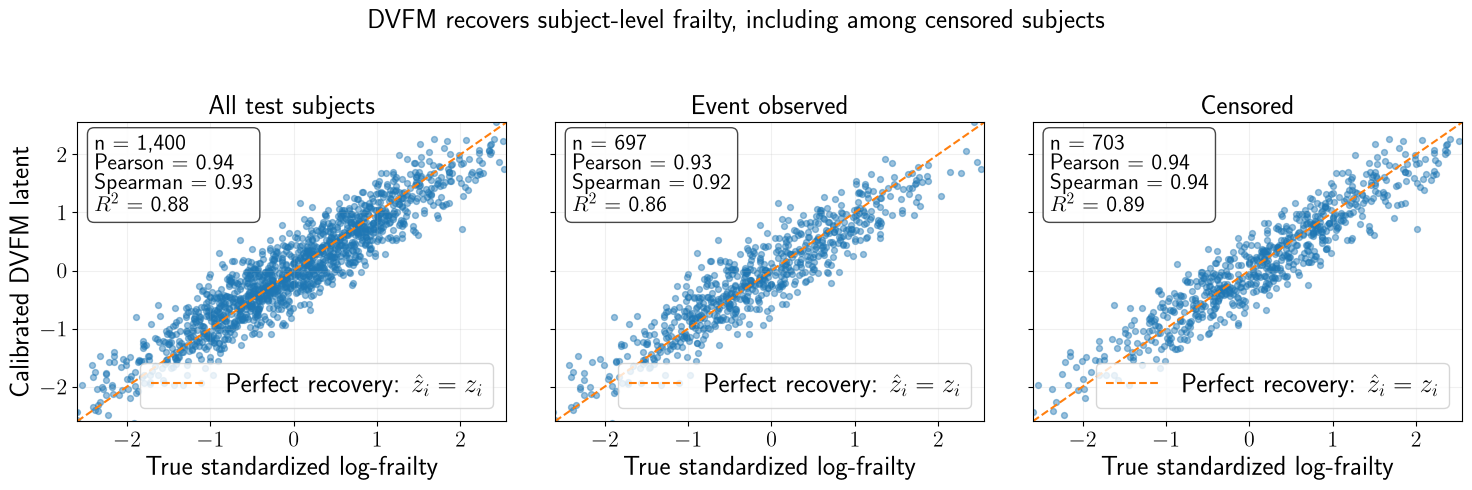

wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_subject_frailty_recovery.pdf


In [7]:
def central_limits(frame, x_col, y_col, lower_q=0.01, upper_q=0.99):
    x_low, x_high = frame[x_col].quantile([lower_q, upper_q])
    y_low, y_high = frame[y_col].quantile([lower_q, upper_q])
    lower, upper = float(min(x_low, y_low)), float(max(x_high, y_high))
    padding = 0.04 * (upper - lower)
    return lower - padding, upper + padding

limit_low, limit_high = central_limits(frailty_test, "true_z", "learned_z_calibrated")
panels = [
    ("All test subjects", np.ones(len(frailty_test), dtype=bool)),
    ("Event observed", frailty_test["event"].to_numpy() == 1),
    ("Censored", frailty_test["event"].to_numpy() == 0),
]
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), sharex=True, sharey=True)
for ax, (title, mask) in zip(axes, panels):
    subset = frailty_test.loc[mask]
    x = subset["true_z"].to_numpy()
    y = subset["learned_z_calibrated"].to_numpy()
    pearson = float(pd.Series(x).corr(pd.Series(y), method="pearson"))
    spearman = float(pd.Series(x).corr(pd.Series(y), method="spearman"))
    r2 = float(1 - np.sum((y - x) ** 2) / np.sum((x - x.mean()) ** 2))
    ax.scatter(x, y, alpha=0.45, s=18)
    ax.plot(
        [limit_low, limit_high], [limit_low, limit_high],
        linestyle="--", linewidth=1.5, color="#ff7f0e",
        label=r"Perfect recovery: $\hat{z}_i = z_i$",
    )
    ax.text(
        0.04, 0.96,
        f"n = {len(subset):,}\nPearson = {pearson:.2f}\nSpearman = {spearman:.2f}\n$R^2$ = {r2:.2f}",
        transform=ax.transAxes, va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "0.2", "alpha": 0.9},
    )
    ax.set(xlim=(limit_low, limit_high), ylim=(limit_low, limit_high), title=title)
    ax.grid(alpha=0.18)
    ax.set_xlabel("True standardized log-frailty")
    ax.legend(loc="lower right", frameon=True)
axes[0].set_ylabel("Calibrated DVFM latent")
fig.suptitle("DVFM recovers subject-level frailty, including among censored subjects", y=1.03)
fig.tight_layout()
out = FIGURE_DIR / "semi_synthetic_subject_frailty_recovery.pdf"
fig.savefig(out)
plt.show()
print(f"wrote {out}")


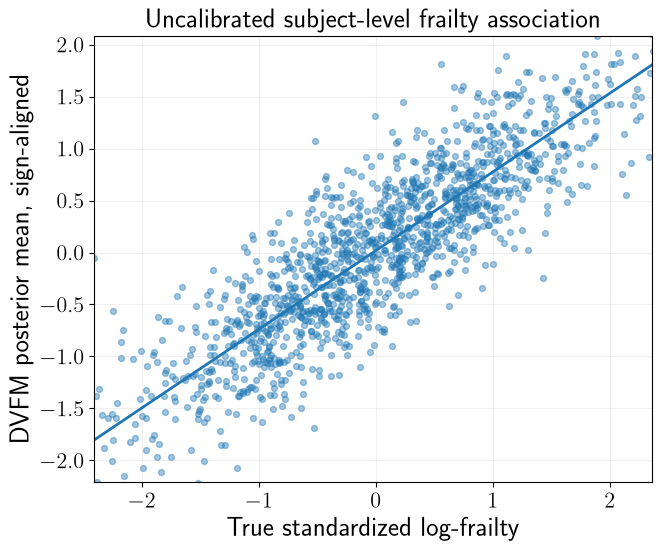

wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_subject_frailty_uncalibrated.pdf


In [8]:
x = frailty_test["true_z"].to_numpy()
y = frailty_test["learned_mu_aligned"].to_numpy()
x_low, x_high = np.quantile(x, [0.01, 0.99])
y_low, y_high = np.quantile(y, [0.01, 0.99])
slope, intercept = np.polyfit(x, y, 1)
grid = np.linspace(x_low, x_high, 200)
fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.scatter(x, y, alpha=0.42, s=18)
ax.plot(grid, intercept + slope * grid, linewidth=2)
ax.set(xlim=(x_low, x_high), ylim=(y_low, y_high),
       xlabel="True standardized log-frailty",
       ylabel="DVFM posterior mean, sign-aligned",
       title="Uncalibrated subject-level frailty association")
ax.grid(alpha=0.18)
out = FIGURE_DIR / "semi_synthetic_subject_frailty_uncalibrated.pdf"
fig.savefig(out)
plt.show()
print(f"wrote {out}")


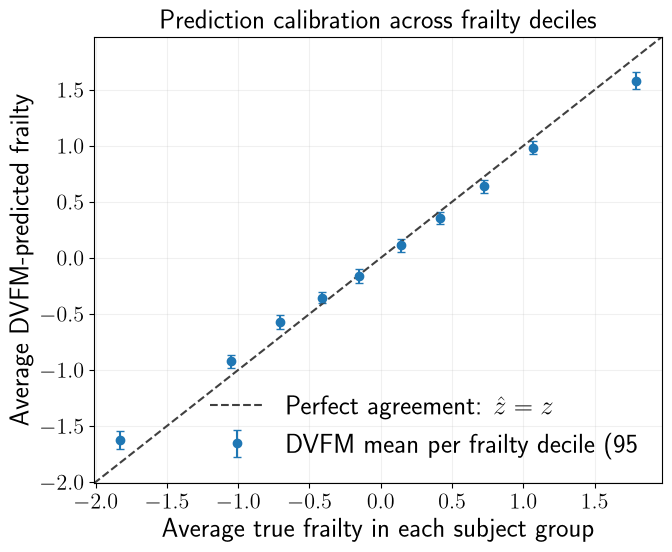

wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_subject_frailty_deciles.pdf


In [9]:
deciles = frailty_test.copy()
deciles["true_z_decile"] = pd.qcut(deciles["true_z"], q=10, duplicates="drop")
binned = deciles.groupby("true_z_decile", observed=True).agg(
    true_z_mean=("true_z", "mean"),
    calibrated_mean=("learned_z_calibrated", "mean"),
    calibrated_sd=("learned_z_calibrated", "std"),
    n=("true_z", "size"),
).reset_index(drop=True)
binned["sem"] = binned["calibrated_sd"] / np.sqrt(binned["n"])
lower = float(min(binned["true_z_mean"].min(), binned["calibrated_mean"].min()))
upper = float(max(binned["true_z_mean"].max(), binned["calibrated_mean"].max()))
padding = 0.05 * (upper - lower)
fig, ax = plt.subplots(figsize=(7.0, 5.8))
ax.errorbar(binned["true_z_mean"], binned["calibrated_mean"], yerr=1.96 * binned["sem"],
            fmt="o", capsize=3, label="DVFM mean per frailty decile (95% CI)")
ax.plot([lower - padding, upper + padding], [lower - padding, upper + padding], "--", color="0.25",
        label=r"Perfect agreement: $\hat{z}=z$")
ax.set(xlim=(lower - padding, upper + padding), ylim=(lower - padding, upper + padding),
       xlabel="Average true frailty in each subject group",
       ylabel="Average DVFM-predicted frailty",
       title="Prediction calibration across frailty deciles")
ax.grid(alpha=0.18)
ax.legend(frameon=False)
fig.tight_layout()
out = FIGURE_DIR / "semi_synthetic_subject_frailty_deciles.pdf"
fig.savefig(out)
plt.show()
print(f"wrote {out}")


## Tables

The notebook writes booktabs-compatible LaTeX directly. Table 1 describes the datasets. Table 2 reports scenario-balanced ranks and paired wins/ties/losses; full dataset-by-model values belong in the supplement.

In [10]:
if characteristics is None:
    print("dataset_characteristics.csv is absent; write this file during generation to enable Table 1.")
else:
    dataset_table = characteristics.copy()
    for column in dataset_table.select_dtypes(include="number"):
        if "rate" in column.lower():
            dataset_table[column] = dataset_table[column].map(lambda value: f"{value:.2f}")
    latex = dataset_table.to_latex(
        index=False, escape=False,
        caption="Characteristics of the source datasets used for semi-synthetic evaluation.",
        label="tab:semi_synthetic_datasets",
        column_format="l" + "r" * (len(dataset_table.columns) - 1),
    )
    out = TABLE_DIR / "semi_synthetic_datasets.tex"
    out.write_text(latex, encoding="utf-8")
    print(latex)
    print(f"{DATA_SOURCE} | wrote {out}")

\begin{table}
\caption{Characteristics of the source datasets used for semi-synthetic evaluation.}
\label{tab:semi_synthetic_datasets}
\begin{tabular}{lrrrrr}
\toprule
Dataset & $N$ & Raw features & Encoded features & Original censoring rate & Split \\
\midrule
whas & 500 & 14 & 14 & 0.57 & 70/10/20 \\
gbsg & 686 & 8 & 8 & 0.56 & 70/10/20 \\
metabric & 1902 & 9 & 9 & 0.42 & 70/10/20 \\
churn & 1958 & 12 & 25 & 0.52 & 70/10/20 \\
nacd & 2396 & 48 & 48 & 0.36 & 70/10/20 \\
flchain & 7871 & 8 & 16 & 0.72 & 70/10/20 \\
support & 8873 & 14 & 27 & 0.32 & 70/10/20 \\
employee & 14999 & 8 & 17 & 0.76 & 70/10/20 \\
mimic_iv & 38520 & 91 & 103 & 0.67 & 70/10/20 \\
seer_brain & 73703 & 10 & 10 & 0.40 & 70/10/20 \\
seer_liver & 82841 & 14 & 14 & 0.38 & 70/10/20 \\
seer_stomach & 100360 & 14 & 14 & 0.43 & 70/10/20 \\
\bottomrule
\end{tabular}
\end{table}

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_datasets.tex


In [11]:
comparison = results[~results["model"].eq("DVFM-z0")].copy()
scenario_keys = ["dataset", "copula", "target_kendall_tau", "target_censoring_rate"]
scenario_model = comparison.groupby(scenario_keys + ["model"], as_index=False).agg(
    oracle_ibs=("oracle_ibs", "mean"), oracle_ci=("oracle_ci", "mean"), oracle_mae=("oracle_mae", "mean"),
    failures=("numerical_failure", "sum"),
)
scenario_model["ibs_rank"] = scenario_model.groupby(scenario_keys)["oracle_ibs"].rank(method="average")
scenario_model["ci_rank"] = scenario_model.groupby(scenario_keys)["oracle_ci"].rank(method="average", ascending=False)
scenario_model["mae_rank"] = scenario_model.groupby(scenario_keys)["oracle_mae"].rank(method="average")
rank_table = scenario_model.groupby("model", as_index=False).agg(
    IBS=("ibs_rank", "mean"), CI=("ci_rank", "mean"), MAE=("mae_rank", "mean"), Failures=("failures", "sum"),
)
dvfm_ibs = scenario_model[scenario_model["model"].eq("DVFM")][scenario_keys + ["oracle_ibs"]].rename(columns={"oracle_ibs": "dvfm_ibs"})
paired_models = scenario_model.merge(dvfm_ibs, on=scenario_keys, how="left")
tol = 1e-4
paired_models["outcome"] = np.where(paired_models["oracle_ibs"] < paired_models["dvfm_ibs"] - tol, "W", np.where(paired_models["oracle_ibs"] > paired_models["dvfm_ibs"] + tol, "L", "T"))
wtl = paired_models.groupby(["model", "outcome"]).size().unstack(fill_value=0).reindex(columns=["W", "T", "L"], fill_value=0)
wtl["W/T/L vs DVFM"] = wtl.astype(int).astype(str).agg("/".join, axis=1)
rank_table = rank_table.merge(wtl[["W/T/L vs DVFM"]], left_on="model", right_index=True, how="left")
rank_table.loc[rank_table["model"].eq("DVFM"), "W/T/L vs DVFM"] = "--"
rank_table = rank_table.sort_values("IBS").rename(columns={"model": "Model", "IBS": "IBS rank", "CI": "CI rank", "MAE": "MAE rank"})
for column in ["IBS rank", "CI rank", "MAE rank"]:
    rank_table[column] = rank_table[column].map(lambda value: f"{value:.2f}")
rank_table["Failures"] = rank_table["Failures"].astype(int)
latex = rank_table.to_latex(
    index=False, escape=False,
    caption="Scenario-balanced semi-synthetic performance. Lower mean rank is better. Wins, ties, and losses use oracle IBS and are reported from each comparator's perspective.",
    label="tab:semi_synthetic_models",
    column_format="lrrrrr",
)
out = TABLE_DIR / "semi_synthetic_model_summary.tex"
out.write_text(latex, encoding="utf-8")
print(latex)
print(f"{DATA_SOURCE} | wrote {out}")

\begin{table}
\caption{Scenario-balanced semi-synthetic performance. Lower mean rank is better. Wins, ties, and losses use oracle IBS and are reported from each comparator's perspective.}
\label{tab:semi_synthetic_models}
\begin{tabular}{lrrrrr}
\toprule
Model & IBS rank & CI rank & MAE rank & Failures & W/T/L vs DVFM \\
\midrule
DVFM & 1.00 & 1.04 & 1.03 & 0 & -- \\
HACSurv & 2.01 & 2.26 & 2.26 & 0 & 0/0/156 \\
ClaytonAFT & 2.99 & 2.99 & 2.96 & 0 & 0/0/156 \\
BayesianCoxGammaFrailty & 4.01 & 4.49 & 4.40 & 0 & 0/0/156 \\
GBSA & 5.27 & 5.99 & 5.90 & 0 & 0/0/156 \\
MTLR & 6.08 & 6.40 & 6.07 & 0 & 0/0/156 \\
DeepSurv & 6.76 & 6.67 & 6.77 & 0 & 0/0/156 \\
RSF & 7.94 & 7.26 & 7.47 & 0 & 0/0/156 \\
CoxPH & 8.96 & 7.90 & 8.14 & 0 & 0/0/156 \\
\bottomrule
\end{tabular}
\end{table}

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_model_summary.tex
